In [45]:
# Phase2_Optim.ipynb
# Author: Marianna Gabrielyan, 20260615
# Email: mgabr001@gmail.com


In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import warnings
warnings.filterwarnings('ignore')
import os

import random
from plotnine  import * 

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor
import forestci as fci

import dice_ml
from quantile_forest import RandomForestQuantileRegressor
import shap



%matplotlib inline


In [47]:
# Read in input file

path = '/home/mgabr001/BrainGenix/BrainEmulationChallenge/src/models/autoassociative/NetmorphParOptim'
os.chdir(path)

df = pd.read_excel(open('Phase1_1500_samples-labeled-RS20240628.xlsx','rb'))    

print(df.shape)
print(df.columns)



(1497, 8)
Index(['days', 'pyramidal', 'minneuronseparation', 'shape.radius',
       'shape.thickness', 'dm.weight', 'usable_conns1', 'usable_conns2'],
      dtype='str')


In [48]:
# Select Only Needed Columns

columnsA = ['days', 'pyramidal', 'minneuronseparation',
       'shape.radius', 'shape.thickness', 'dm.weight', 'usable_conns1',
       'usable_conns2']


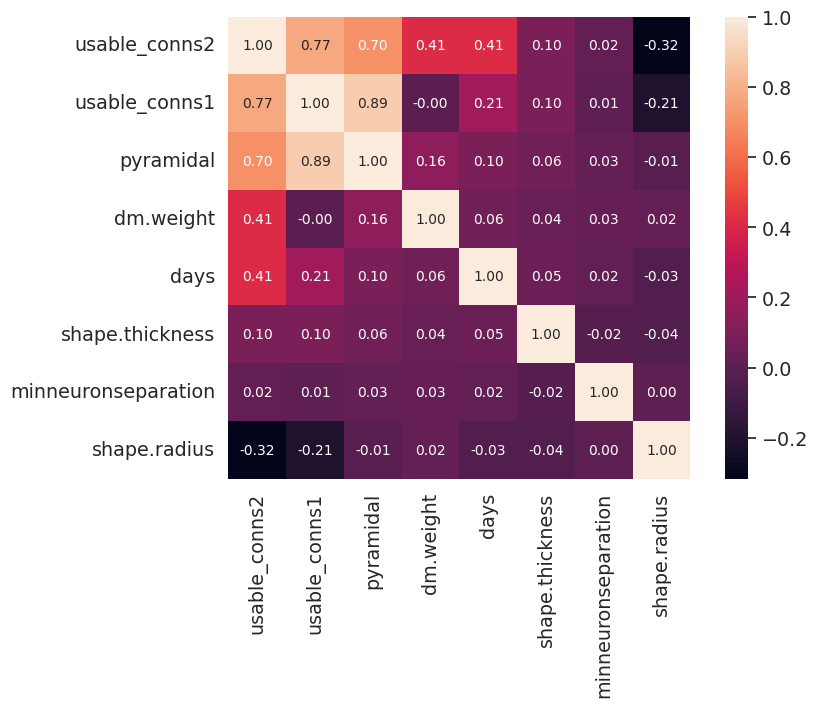

In [49]:

# correlation matrix
f, ax = plt.subplots(figsize=(9, 6))
k = 10 #number of variables for heatmap
corrmat = df[columnsA].corr()
cols = corrmat.nlargest(k, 'usable_conns2')['usable_conns2'].index
cm = np.corrcoef(df[cols].values.T)
sns.set(font_scale=1.25)
hm = sns.heatmap(cm, cbar=True, annot=True, square=True, fmt='.2f', annot_kws={'size': 10}, yticklabels=cols.values, xticklabels=cols.values)
plt.show()
f.savefig('Correlation_Matrix.png')

In [50]:
df = df[(df['usable_conns2'] <= 2500) & (df['usable_conns2'] >= 0)]
df.reset_index(drop=True, inplace=True)
print(df.shape[0])

1403


## Create Training and Test datasets: split 80% and 20%

In [51]:
cols = ['days', 'pyramidal', 'minneuronseparation',
       'shape.radius', 'shape.thickness', 'dm.weight']

In [52]:
X_train, X_test, y_train, y_test = train_test_split(df[cols],df['usable_conns2'], test_size=0.2, random_state=27)
X_train.shape

(1122, 6)

In [53]:
print(X_train.head())
print(y_train.head()) 

     days  pyramidal  minneuronseparation  shape.radius  shape.thickness  \
681    25         80                   10           140               40   
45     21         64                   13           100               30   
206    25        112                   11           160               50   
837    23        112                   10           120               40   
611    23        120                   12           180               20   

     dm.weight  
681        0.9  
45         0.8  
206        0.1  
837        1.0  
611        0.8  
681    1172
45      802
206     150
837    2240
611    1388
Name: usable_conns2, dtype: int64


In [54]:
clf = RandomForestRegressor(n_estimators=1000, bootstrap = True, oob_score = True, random_state = 27)
model = clf.fit(X_train, y_train)

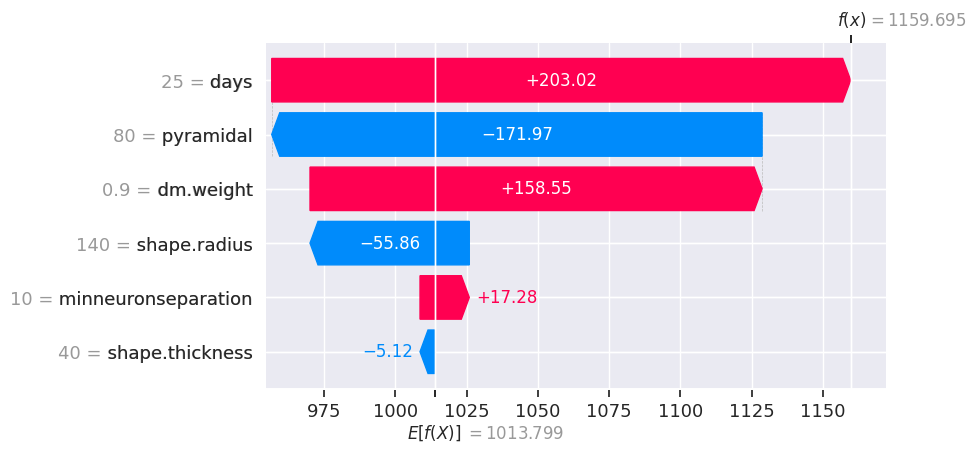

In [55]:
# explain the model's predictions using SHAP
# (same syntax works for LightGBM, CatBoost, scikit-learn, transformers, Spark, etc.)

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_train)

# visualize the first prediction's explanation
shap.plots.waterfall(shap_values[0])

In [56]:
# shap.summary_plot(shap_values, X_train)

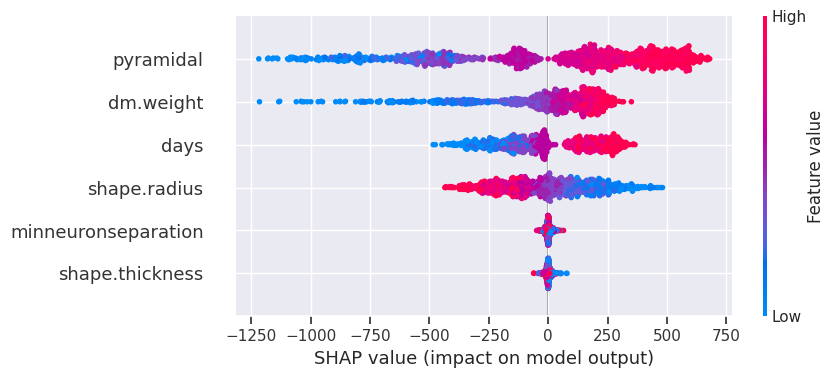

In [57]:
# summarize the effects of all the features
shap.plots.beeswarm(shap_values)

In [58]:
# shap.TreeExplainer(model).shap_interaction_values(X_train)

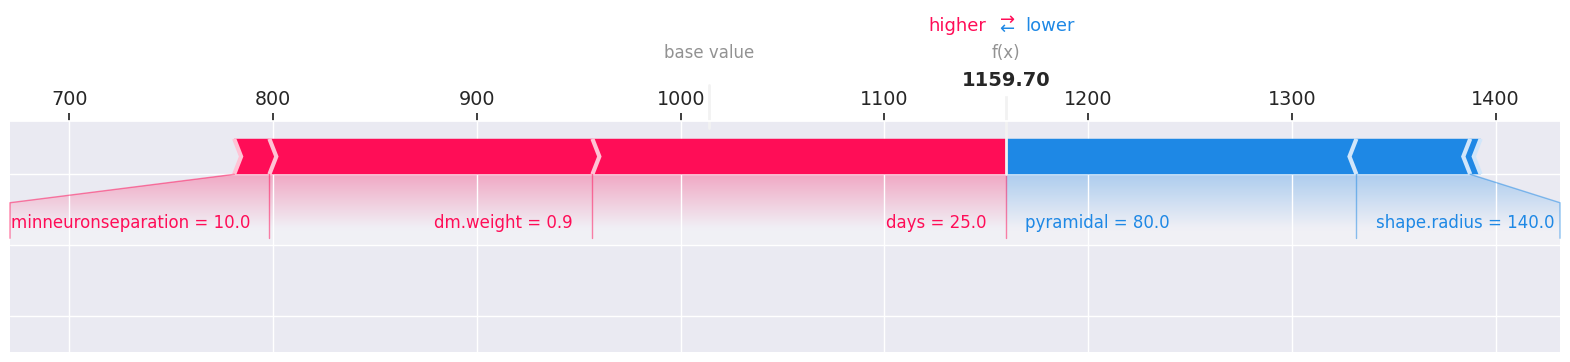

In [59]:
# visualize the first prediction's explanation with a force plot
shap.plots.force(shap_values[0], matplotlib=True)

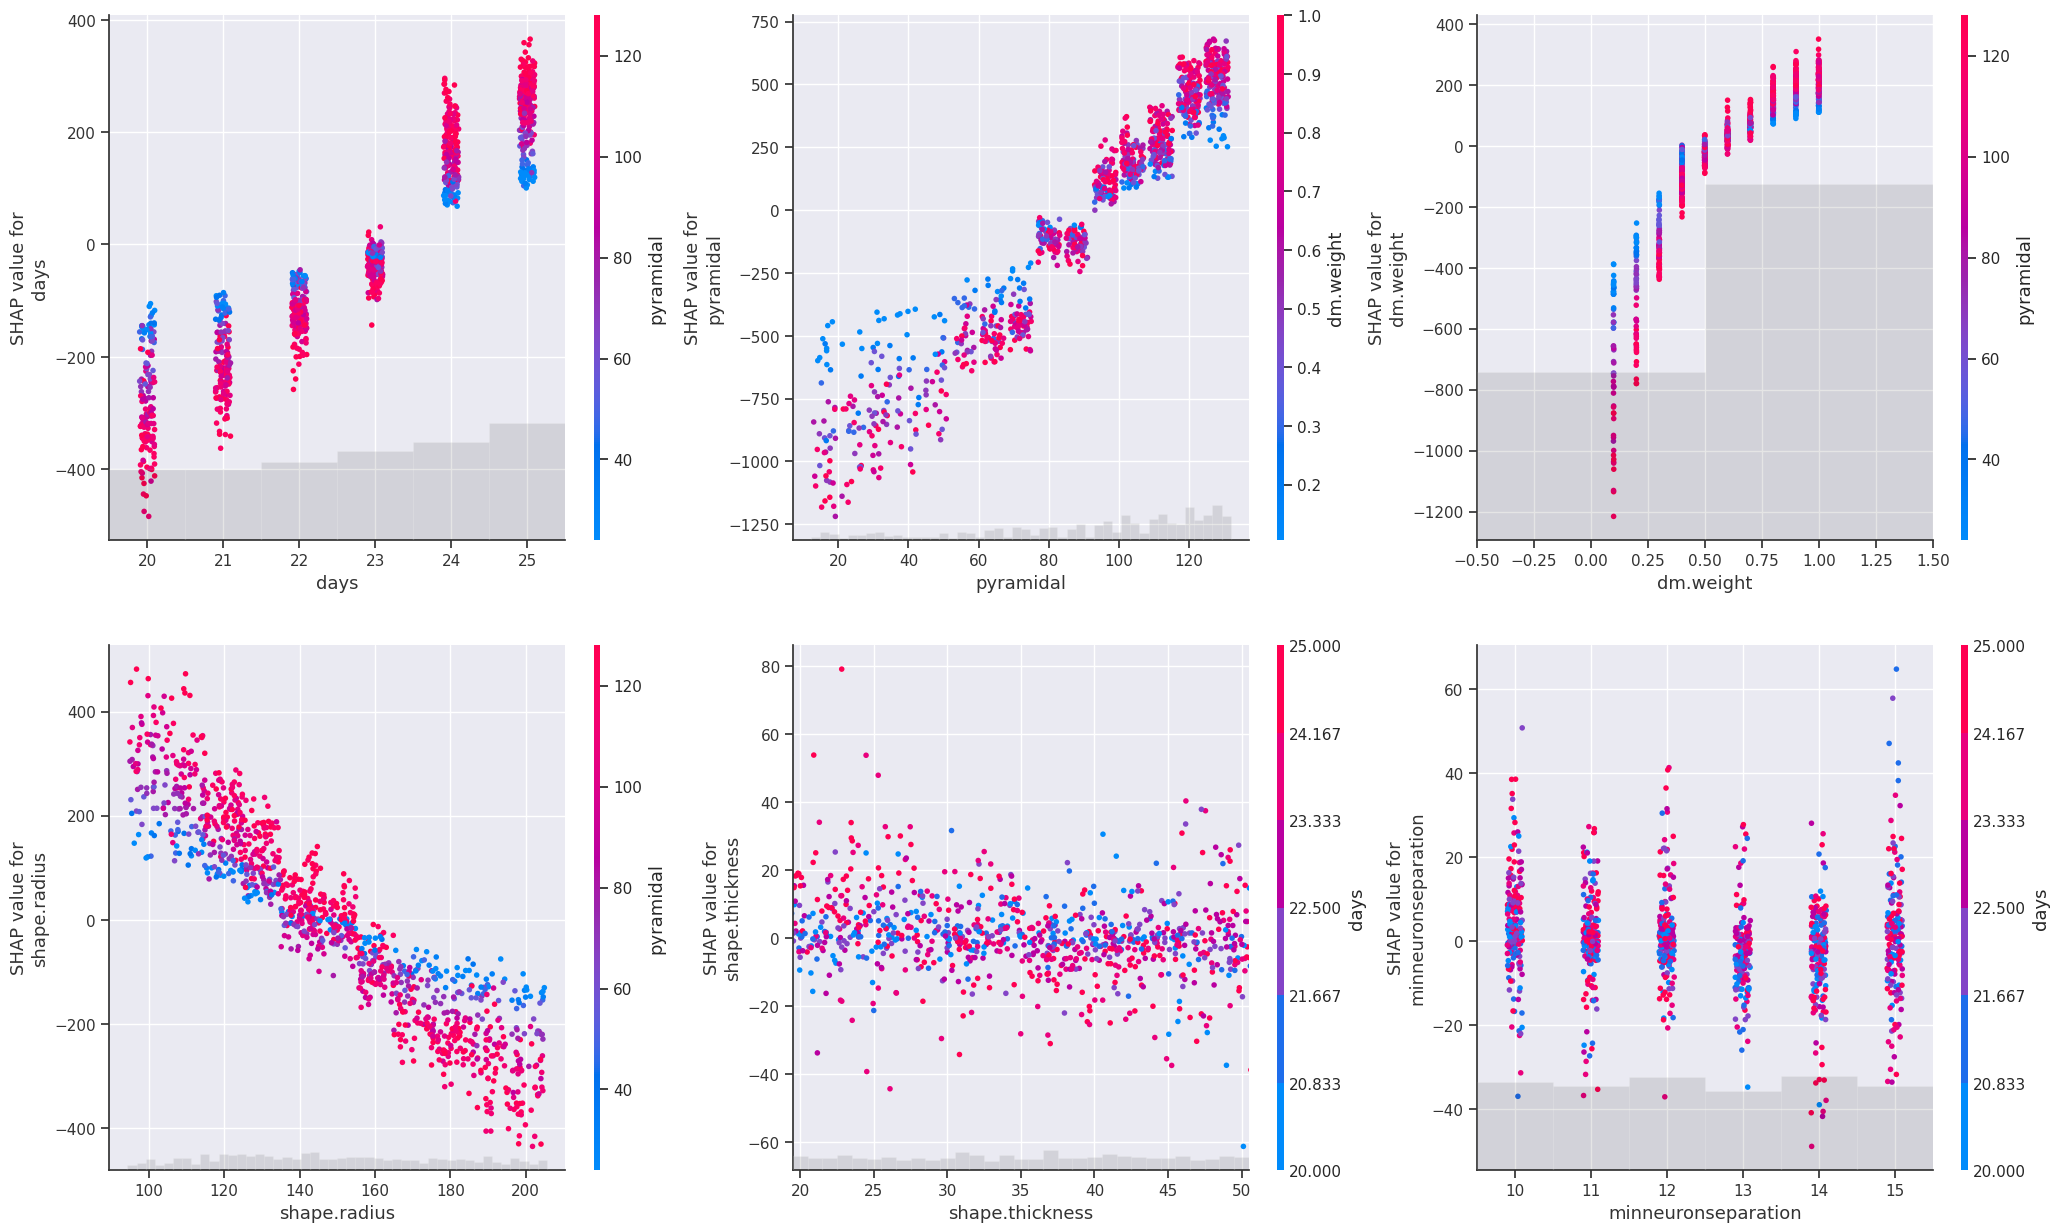

In [60]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(25, 15))

shap.plots.scatter(shap_values[:, "days"], ax=axes[0, 0], color=shap_values, show=False)
shap.plots.scatter(shap_values[:, "pyramidal"], ax=axes[0, 1], color=shap_values, show=False)
shap.plots.scatter(shap_values[:, "dm.weight"], ax=axes[0, 2], color=shap_values, show=False)
shap.plots.scatter(shap_values[:, "shape.radius"], ax=axes[1, 0], color=shap_values, show=False)
shap.plots.scatter(shap_values[:, "shape.thickness"], ax=axes[1, 1], color=shap_values, show=False)
shap.plots.scatter(shap_values[:, "minneuronseparation"], ax=axes[1, 2], color=shap_values, show=False)

plt.show()

In [61]:
shap_values.shape

(1122, 6)

In [62]:
shap_values[0]

.values =
array([ 203.02453952, -171.97329604,   17.27563846,  -55.85792075,
         -5.1197109 ,  158.54677645])

.base_values =
np.float64(1013.7989732620322)

.data =
array([ 25. ,  80. ,  10. , 140. ,  40. ,   0.9])

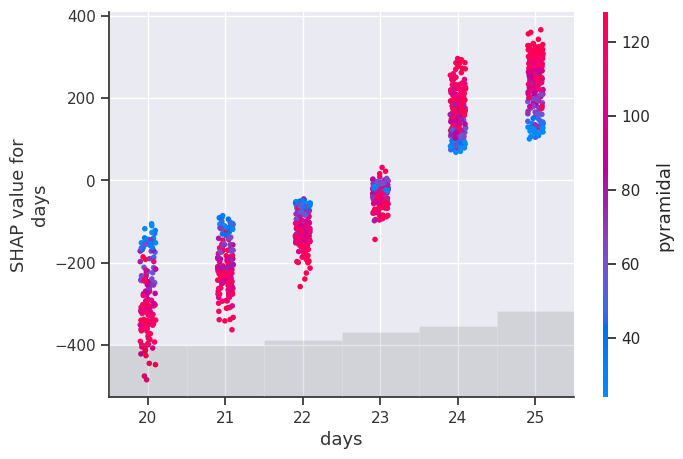

In [63]:
# create a dependence scatter plot to show the effect of a single feature across the whole dataset
shap.plots.scatter(shap_values[:, "days"], color=shap_values)

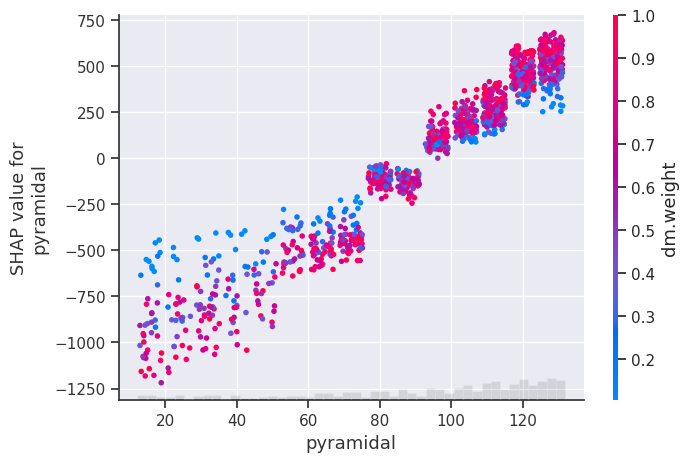

In [64]:
# create a dependence scatter plot to show the effect of a single feature across the whole dataset
shap.plots.scatter(shap_values[:, "pyramidal"], color=shap_values)

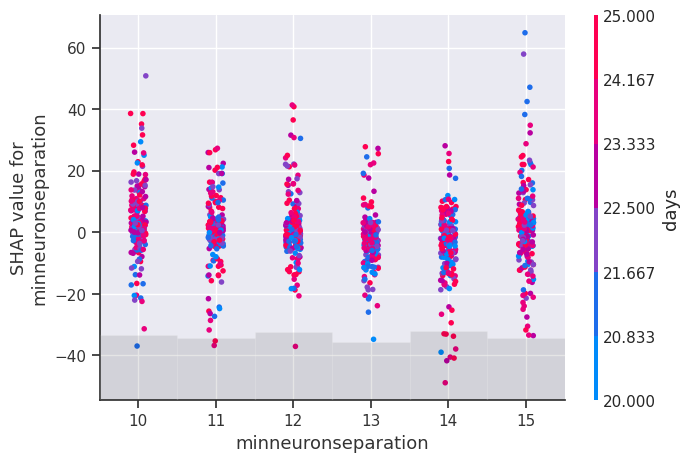

In [65]:
shap.plots.scatter(shap_values[:, "minneuronseparation"], color=shap_values)

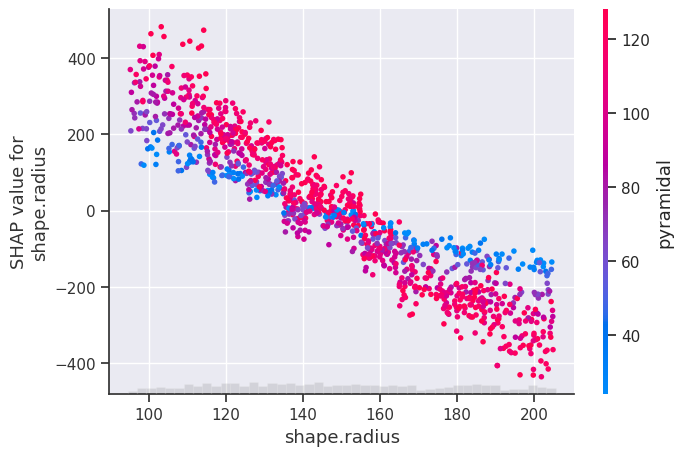

In [66]:
shap.plots.scatter(shap_values[:, "shape.radius"], color=shap_values)

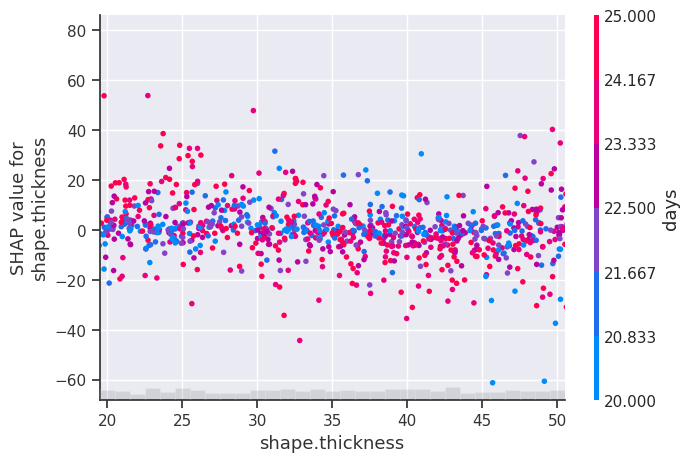

In [67]:
shap.plots.scatter(shap_values[:, "shape.thickness"], color=shap_values)

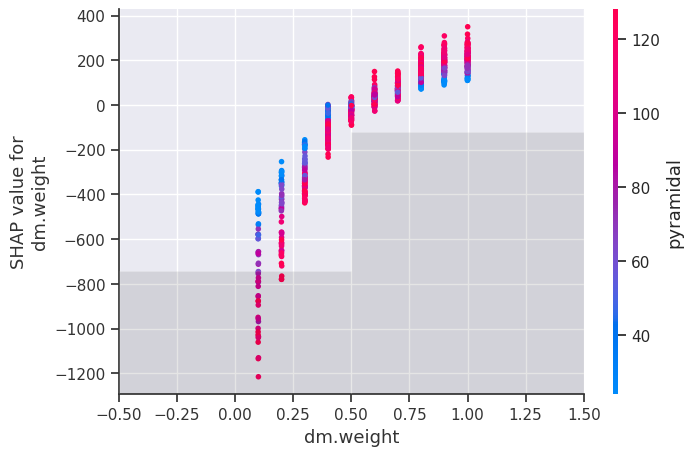

In [68]:
shap.plots.scatter(shap_values[:, "dm.weight"], color=shap_values)

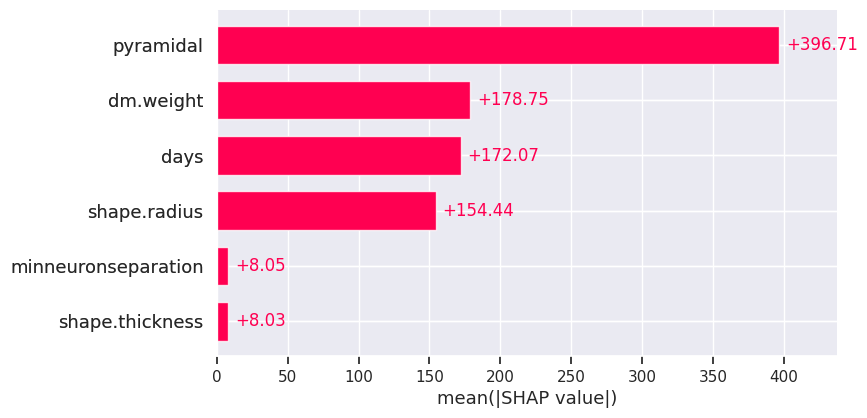

In [69]:
shap.plots.bar(shap_values)

## Create Paartial Dependence Plots (PDP)

#### PDP = average of model outcomes for fixed feature xi, while others vary.

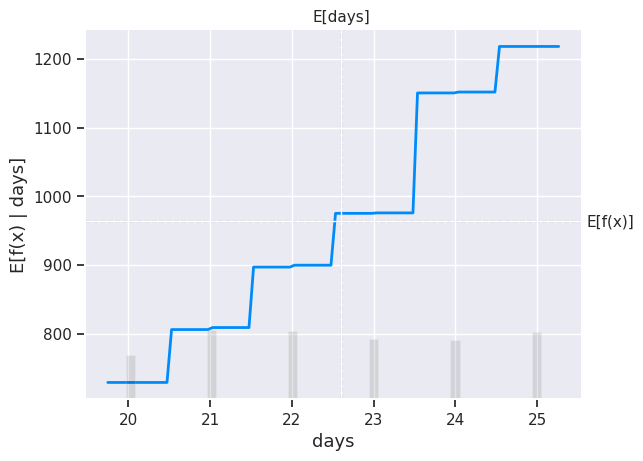

In [70]:
shap.partial_dependence_plot(
    "days",
    model.predict,
    X_test[cols],
    ice=False,
    model_expected_value=True,
    feature_expected_value=True,
)

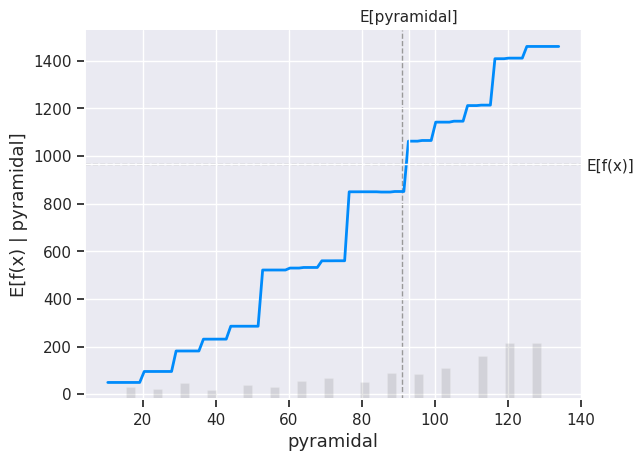

In [71]:
shap.partial_dependence_plot(
    "pyramidal",
    model.predict,
    X_test[cols],
    ice=False,
    model_expected_value=True,
    feature_expected_value=True,
)

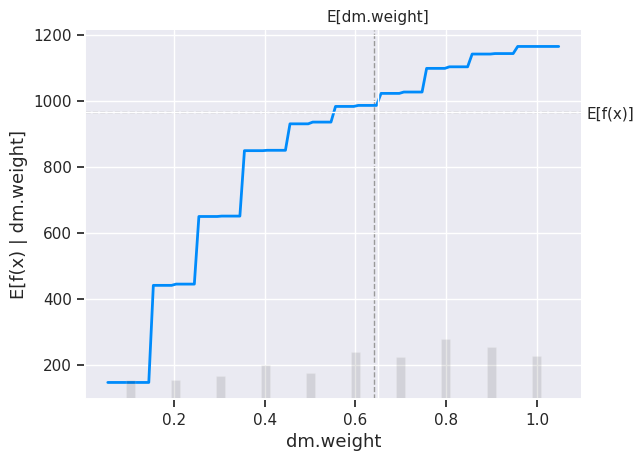

In [72]:
shap.partial_dependence_plot(
    "dm.weight",
    model.predict,
    X_test[cols],
    ice=False,
    model_expected_value=True,
    feature_expected_value=True,
)

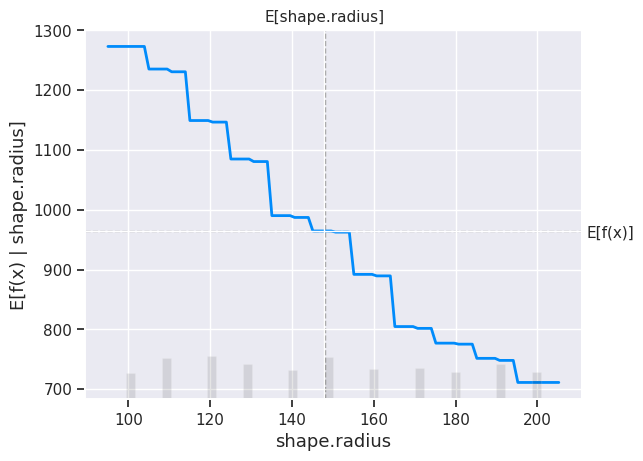

In [73]:
shap.partial_dependence_plot(
    "shape.radius",
    model.predict,
    X_test[cols],
    ice=False,
    model_expected_value=True,
    feature_expected_value=True,
)

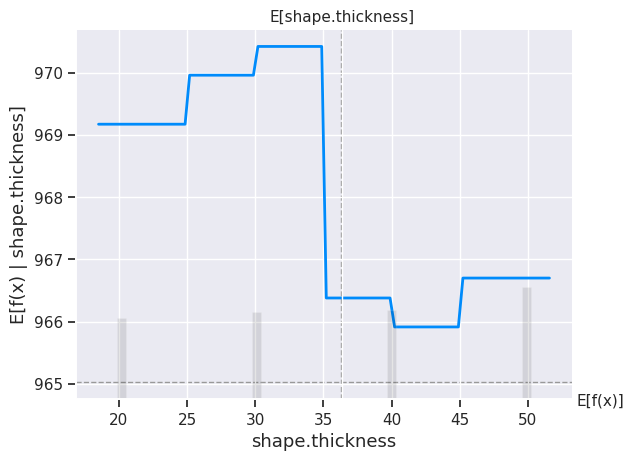

In [74]:
shap.partial_dependence_plot(
    "shape.thickness",
    model.predict,
    X_test[cols],
    ice=False,
    model_expected_value=True,
    feature_expected_value=True,
)

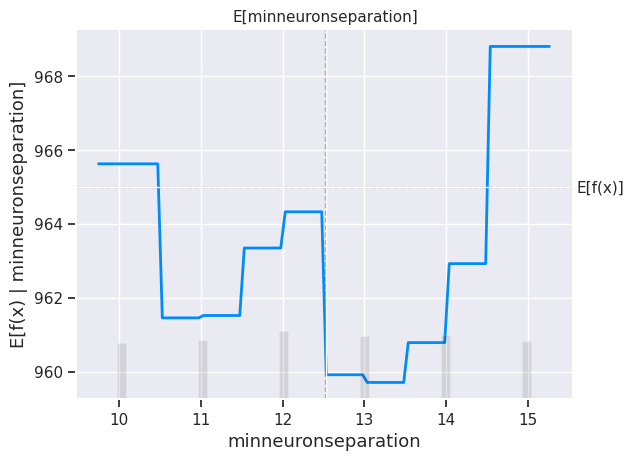

In [75]:
shap.partial_dependence_plot(
    "minneuronseparation",
    model.predict,
    X_test[cols],
    ice=False,
    model_expected_value=True,
    feature_expected_value=True,
)

#### Recreate Training and Test Datasets to make sure there are no additional columns

In [76]:
X_train, X_test, y_train, y_test = train_test_split(df[cols],df['usable_conns2'], test_size=0.2)
X_train.shape

(1122, 6)

# Generate Diverse Counterfactual Explanations (DiCE)

In [77]:
qrf = RandomForestQuantileRegressor(n_estimators=1000, bootstrap = True, oob_score = True, default_quantiles=0.025)
qrf.fit(X_train, y_train)

# If your oob_score is high (e.g., > 0.8), model is generalizing well.
# If your oob_score is low but your training score is high, your model is "memorizing" the training simulations 
# and your uncertainty intervals (error bars) will be lies—they will look small, but the model will fail on new unseen simulations.

print("OOB Score = ", qrf.oob_score_)

# Get OOB predictions (Predictions on the training set using only 'unseen' trees)
# This is a 'honest' way to see how the model performs on known data
oob_preds = qrf.predict(X_train[cols], quantiles=[0.025, 0.5, 0.975], oob_score=True)

# Check: Do ~95% of your actual training labels fall within these OOB intervals?
# If yes, your error bars are well-calibrated.

# Separate the OOB bounds
oob_lower = oob_preds[:, 0]
oob_median = oob_preds[:, 1]
oob_upper = oob_preds[:, 2]


OOB Score =  0.9111419724068766


#### Predict usable_conns2 on training data using Best Fit Model

Create Upper and lower bounds of 95% Prediction Interval for each prediction in the Training and Test Datasets.

In [78]:
# predict on training data
X_train['Pred_usable_conns2'] = oob_median
X_train['lower']=oob_lower
X_train['upper']=oob_upper
X_train['usable_conns2'] = y_train


In [79]:
# Predict on test data. Since the Model has never seen test data, we can use the full model (all trees) to predict on test data (No need for OOB).

X_test['Pred_usable_conns2'] = qrf.predict(X_test[cols], quantiles=0.5)
X_test['lower']=qrf.predict(X_test[cols], quantiles=0.025) 
X_test['upper']=qrf.predict(X_test[cols], quantiles=0.975) 
X_test['usable_conns2'] = y_test

In [80]:
X_train.head()

,days,pyramidal,minneuronseparation,shape.radius,shape.thickness,dm.weight,Pred_usable_conns2,lower,upper,usable_conns2
1239,22,120,12,140,50,1.0,1657.0,1211.0,2234.0,1973
546,21,120,14,120,30,0.4,1447.0,880.5,1963.0,1117
949,24,96,13,200,50,1.0,1160.0,746.0,1821.0,1092
149,22,24,14,110,20,0.9,104.0,74.0,131.0,129
668,22,104,12,160,30,0.5,850.0,666.0,1201.0,906


In [81]:
X_test.head()

,days,pyramidal,minneuronseparation,shape.radius,shape.thickness,dm.weight,Pred_usable_conns2,lower,upper,usable_conns2
1116,23,80,13,110,20,0.9,1190.0,654.0,1594.725,1213
525,21,96,14,180,20,0.4,443.0,274.0,850.000,539
435,20,104,14,120,40,0.5,1070.0,683.0,1474.000,804
1025,25,128,10,180,40,0.4,1069.0,699.0,1821.000,1373
169,23,48,11,120,20,1.0,446.0,119.0,490.000,421


In [82]:

# 2. Create a "Conservative" Model Wrapper
# This wrapper tells the optimizer to look at the BOTTOM of the 95% interval
# Conservative Strategy: Optimize features until the bottom of the 95% interval is above the threshold. This ensures we hit our goal with 97.5% confidence (one-tailed).
class ConservativeModel:
    def __init__(self, model, threshold):
        self.model = model
        self.threshold = threshold
    
    def predict(self, instances):
        # We predict the 0.025 quantile (Lower Bound)
        # If the Lower Bound > threshold, we are 97.5% sure the real value is too.
        return self.model.predict(instances, quantiles=0.025)

In [83]:

# Wrap the model for DiCE
conservative_wrapper = ConservativeModel(qrf, threshold=500)
m = dice_ml.Model(model=conservative_wrapper, backend="sklearn", model_type='regressor')

# 3. Setup DiCE with specific NETMORPH features
# Setup Data with discrete ranges
# Even if they are integers, we list them in continuous_features 
# so DiCE can explore the range [min, max]
d = dice_ml.Data(dataframe=pd.concat([X_train[cols], y_train], axis=1), 
                 continuous_features=cols, 
                 outcome_name='usable_conns2')

exp = dice_ml.Dice(d, m, method="random")


In [84]:

# 4. Generate Counterfactuals
# We search for parameters where the LOWER BOUND of the model is > threshold
query_instance = X_test[cols].iloc[0:2]
dice_exp = exp.generate_counterfactuals(
    query_instance, 
    total_CFs=7, 
    desired_range=[500.0, 2500.0], # Target range for the lower bound
    permitted_range={'days': [20,25], 
                     'pyramidal': [16, 128], 
                     'minneuronseparation': [10, 15], 
                     'shape.radius': [100, 200], 
                     'shape.thickness': [20.0, 50.0], 
                     'dm.weight': [0.1, 1.0]},
    features_to_vary=list(cols)
)

dice_exp.visualize_as_dataframe(show_only_changes=True)

cf_df = dice_exp.cf_examples_list[0].final_cfs_df



100%|██████████| 2/2 [00:06<00:00,  3.10s/it]

Query instance (original outcome : 654.0)


,days,pyramidal,minneuronseparation,shape.radius,shape.thickness,dm.weight,usable_conns2
0,23,80,13,110,20,0.9,654.0



Diverse Counterfactual set (new outcome: [500.0, 2500.0])


,days,pyramidal,minneuronseparation,shape.radius,shape.thickness,dm.weight,usable_conns2
0,22.0,-,-,136.0,-,-,-
1,-,-,-,-,37.0,1.1,963.0
2,21.0,-,-,-,-,1.0,-
3,25.0,-,-,-,-,-,1112.0
4,-,125.0,-,-,-,-,1682.8499755859375
5,-,-,-,180.0,26.0,-,516.0
6,-,-,-,128.0,-,-,-


Query instance (original outcome : 274.0)


,days,pyramidal,minneuronseparation,shape.radius,shape.thickness,dm.weight,usable_conns2
0,21,96,14,180,20,0.4,274.0



Diverse Counterfactual set (new outcome: [500.0, 2500.0])


,days,pyramidal,minneuronseparation,shape.radius,shape.thickness,dm.weight,usable_conns2
0,25.0,-,-,-,46.0,-,610.0
1,24.0,-,-,-,46.0,-,510.0
2,-,102.0,-,-,-,1.0,552.0750122070312
3,25.0,-,-,-,28.0,-,523.0
4,-,-,-,115.0,-,0.9,914.0
5,-,-,10.0,107.0,-,-,649.0
6,-,-,13.0,101.0,-,-,591.75


In [85]:
print(cf_df.shape)
print(cf_df)


(7, 7)
   days  pyramidal  minneuronseparation  shape.radius  shape.thickness  \
0    22         80                   13           136               20   
1    23         80                   13           110               37   
2    21         80                   13           110               20   
3    25         80                   13           110               20   
4    23        125                   13           110               20   
5    23         80                   13           180               26   
6    23         80                   13           128               20   

   dm.weight  usable_conns2  
0        0.9          626.0  
1        1.1          963.0  
2        1.0          654.0  
3        0.9         1112.0  
4        0.9         1683.0  
5        0.9          516.0  
6        0.9          654.0  


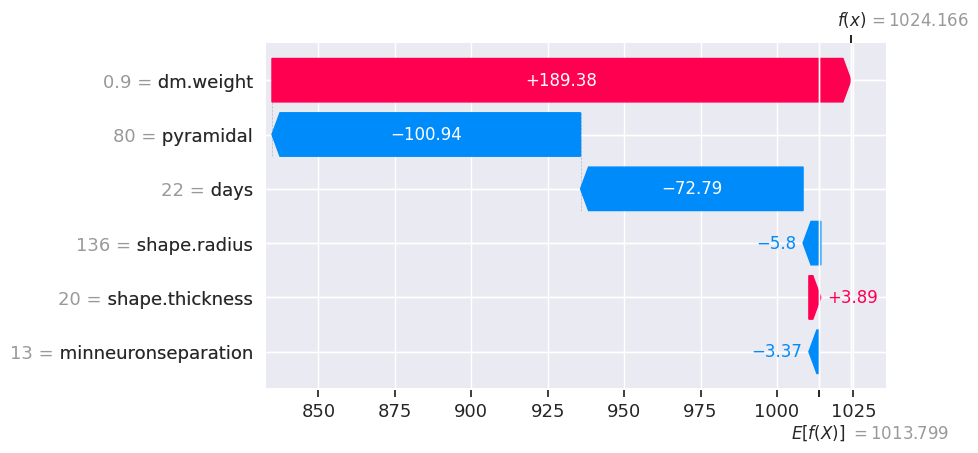

In [86]:
shap_values_cf = explainer(cf_df[cols])
# visualize the cf prediction's explanation
shap.plots.waterfall(shap_values_cf[0])

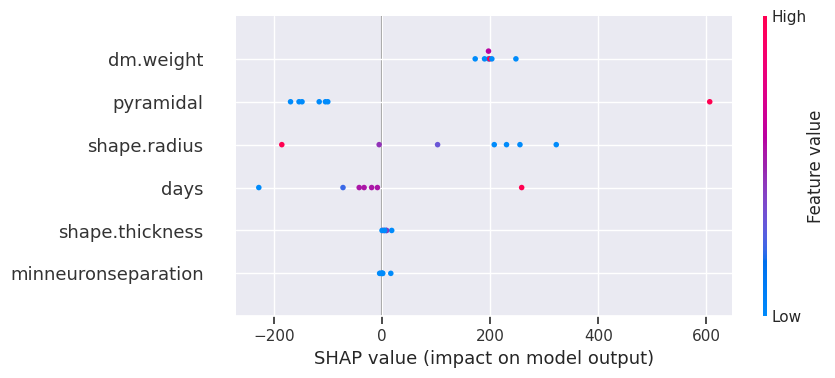

In [87]:
shap.plots.beeswarm(shap_values_cf)

In [88]:
dice_exp.cf_examples_list[0].final_cfs_df

,days,pyramidal,minneuronseparation,shape.radius,shape.thickness,dm.weight,usable_conns2
0,22,80,13,136,20,0.9,626.0
1,23,80,13,110,37,1.1,963.0
2,21,80,13,110,20,1.0,654.0
3,25,80,13,110,20,0.9,1112.0
4,23,125,13,110,20,0.9,1683.0
5,23,80,13,180,26,0.9,516.0
6,23,80,13,128,20,0.9,654.0


In [89]:
X_train.sort_values(by='usable_conns2', ascending=False, inplace = True)
X_train.reset_index(drop=True, inplace=True)


X_test.sort_values(by='usable_conns2', ascending=False, inplace = True)
X_test.reset_index(drop=True, inplace=True)

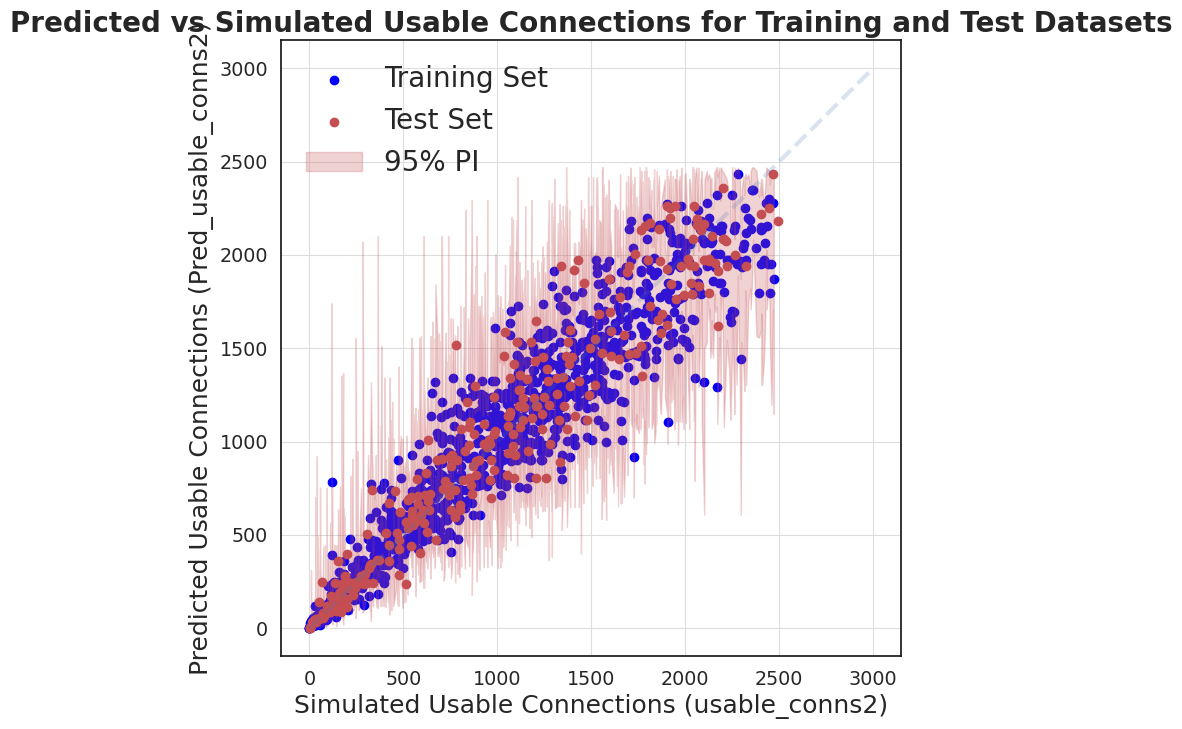

In [90]:
f, ax = plt.subplots(figsize=(8, 8))

plt.scatter(X_train['usable_conns2'], X_train['Pred_usable_conns2'], color ='blue', label = 'Training Set')
plt.scatter(X_test['usable_conns2'],  X_test['Pred_usable_conns2'],color ='r', label = 'Test Set')
# plt.errorbar(X_test['usable_conns2'],  X_test['Pred_usable_conns2'], yerr = X_test['Pred_Usable_Conns_Err'], fmt='o',color ='r', label = 'Test Set')

# plt.fill_between(X_train['usable_conns2'], X_train['Pred_usable_conns2']-1.96*X_train['Pred_Usable_Conns_Err'], X_train['Pred_usable_conns2'] + 1.96*X_train['Pred_Usable_Conns_Err'], color='r', alpha=0.25, label = '95% CI')
# plt.scatter(X_train['usable_conns2'], X_train['Pred_usable_conns2']-1.96*X_train['Pred_Usable_Conns_Err'], color ='cyan', marker='+' )
# plt.scatter(X_train['usable_conns2'], X_train['Pred_usable_conns2']+1.96*X_train['Pred_Usable_Conns_Err'], color ='green', marker='+' )

plt.fill_between(X_train['usable_conns2'], X_train['lower'], X_train['upper'], color='r', alpha=0.25, label = '95% PI')
# plt.scatter(X_train['usable_conns2'], X_train['lower'], color ='cyan', marker='+' )
# plt.scatter(X_train['usable_conns2'], X_train['upper'], color ='green', marker='+' )

plt.plot(np.linspace(0,3000,300), np.linspace(0,3000, 300), 'b--', linewidth=3, alpha= 0.2)

plt.gca().set_facecolor('xkcd:white')
ax.grid(which='major', color='#DDDDDD', linewidth=0.8)


ax.spines['bottom'].set_color('k')
ax.spines['top'].set_color('k')
ax.spines['left'].set_color('k')
ax.spines['right'].set_color('k')

# plt.xlim([0,3500])
# plt.ylim([0,3500])
plt.rc('font', size=18) 
plt.rc('font', size=18) 

plt.title('Predicted vs Simulated Usable Connections for Training and Test Datasets',size = 20, fontweight="bold")
plt.xlabel('Simulated Usable Connections (usable_conns2)',size =18)
plt.ylabel('Predicted Usable Connections (Pred_usable_conns2)',size = 18)
plt.legend(loc='upper left', prop={'size': 20},framealpha=0.)
plt.show()
# f.savefig('Pred_vs_Sim_UsableConns.png')

In [91]:
X_train[(X_train['usable_conns2']==0) & (X_train['Pred_usable_conns2'] > 0)]

,days,pyramidal,minneuronseparation,shape.radius,shape.thickness,dm.weight,Pred_usable_conns2,lower,upper,usable_conns2
1119,20,32,14,190,50,0.1,4.0,0.0,34.0,0
1120,23,16,13,140,30,0.1,4.0,0.0,30.0,0
1121,20,16,11,190,30,0.1,4.0,0.0,30.0,0


In [92]:
X_train[(X_train['usable_conns2'] > 0) & (X_train['Pred_usable_conns2'] == 0.0)]

,days,pyramidal,minneuronseparation,shape.radius,shape.thickness,dm.weight,Pred_usable_conns2,lower,upper,usable_conns2


## Create Full Grid

In [93]:
# Generate the FULL parameter Space

days = np.arange(20, 26, 1)                         # 6
pyramidal= np.arange(16, 136, 8)                    # 15        
minneuronseparation = np.arange(10, 16, 1)          # 6
shape_radius = np.arange(100, 210, 10)              # 11  
shape_thickness = np.arange(20, 60, 10)             # 4
dm_weight = np.arange(0.1, 1.1, 0.1)                # 10

ldays = len(days)
lpyramidal = len(pyramidal)  
lminneuronseparation = len(minneuronseparation)
lshape_radius = len(shape_radius)
lshape_thickness = len(shape_thickness)
ldm_weight = len(dm_weight) 




In [94]:
# N = ldays * lpyramidal * linterneuron * lminneuronseparation * lshape_radius * lshape_thickness * ldm_weight
N = ldays * lpyramidal * lminneuronseparation * lshape_radius * lshape_thickness * ldm_weight
print("N = ", N)
#full grid
arr=[(N,9)]

#######  When created this way, the first row should not be dropped when creating the prediction grid.

arr = [[ days[i], pyramidal[j], minneuronseparation[k], shape_radius[l], shape_thickness[m], dm_weight[n] ] \
    for i in range(ldays) \
    for j in range(lpyramidal) \
    for k in range(lminneuronseparation) \
    for l in range(lshape_radius) \
    for m in range(lshape_thickness) \
    for n in range(ldm_weight)]
  

N =  237600


In [95]:
ldays * lpyramidal * lminneuronseparation * lshape_radius * lshape_thickness * ldm_weight

237600

In [96]:
print("Length of arr:", len(arr))

Length of arr: 237600


In [97]:
print(arr[:1 :])

[[np.int64(20), np.int64(16), np.int64(10), np.int64(100), np.int64(20), np.float64(0.1)]]


# Create a prediction array for the entire parameter space

In [98]:
# Create a prediction array for the entire parameter space

cols = ['days', 
        'pyramidal', 
        'minneuronseparation',
        'shape.radius', 
        'shape.thickness', 
        'dm.weight'
        ]


pred_grid = pd.DataFrame(data = arr, columns = cols)

# pred_grid.drop_duplicates(keep='first', inplace=True)
# pred_grid = pred_grid.iloc[1:]  # drop the first row. 1st row is the total # rows and columns 
pred_grid.shape



(237600, 6)

In [99]:
pred_grid.head()

,days,pyramidal,minneuronseparation,shape.radius,shape.thickness,dm.weight
0,20,16,10,100,20,0.1
1,20,16,10,100,20,0.2
2,20,16,10,100,20,0.3
3,20,16,10,100,20,0.4
4,20,16,10,100,20,0.5


# Predict Usable Connections for the entire parameter space using Best FIT model.

In [100]:
# Make predictions using the Quantile RF regressor on the entire parameter space grid.

oob_preds = qrf.predict(pred_grid[cols], quantiles=[0.025, 0.5, 0.975])

# Separate the OOB bounds
oob_lower = oob_preds[:, 0]
oob_median = oob_preds[:, 1]
oob_upper = oob_preds[:, 2]

pred_grid['Pred_usable_conns2'] = oob_median
pred_grid['lower'] = oob_lower
pred_grid['upper'] = oob_upper

In [101]:
pred_grid.sort_values(by='Pred_usable_conns2', ascending=False, inplace = True)
pred_grid.reset_index(drop=True, inplace=True)
pred_grid.head()


,days,pyramidal,minneuronseparation,shape.radius,shape.thickness,dm.weight,Pred_usable_conns2,lower,upper
0,25,128,11,140,20,0.5,2471.0,1364.100,2471.0
1,25,120,11,140,20,0.5,2471.0,1290.000,2471.0
2,25,128,10,140,20,0.5,2471.0,1364.100,2471.0
3,25,128,10,130,50,0.8,2467.0,1971.675,2467.0
4,25,128,11,130,50,0.9,2467.0,1980.000,2467.0


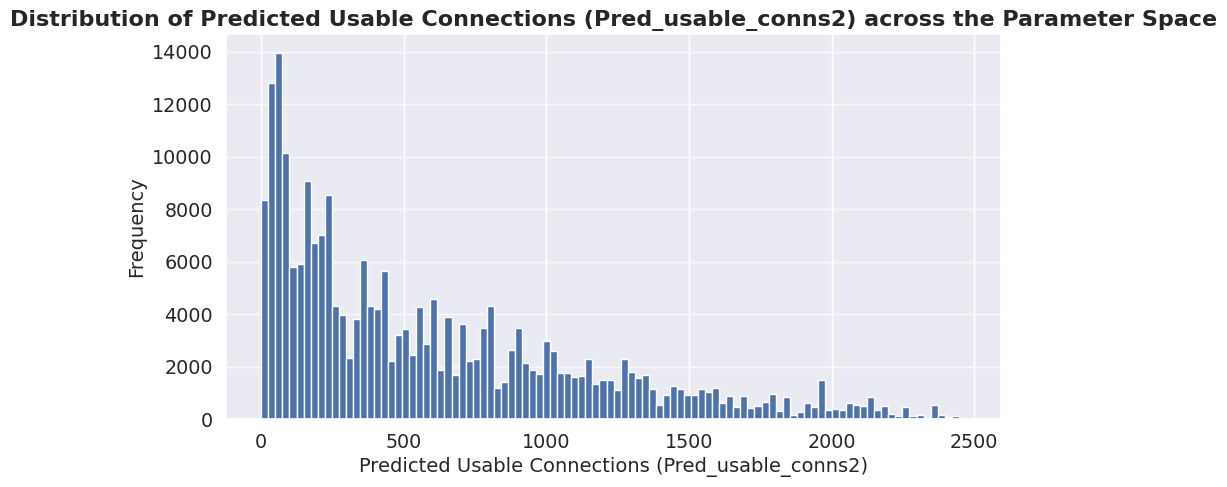

In [102]:
pred_grid.hist(column='Pred_usable_conns2', bins=100, figsize=(10, 5))
plt.title('Distribution of Predicted Usable Connections (Pred_usable_conns2) across the Parameter Space', size=16, fontweight="bold")
plt.xlabel('Predicted Usable Connections (Pred_usable_conns2)', size=14)
plt.ylabel('Frequency', size=14)
plt.grid(axis='y', alpha=0.75)
plt.show()

### Select Samples for the Next Round of Simulations


1. Split the number of rows into 5 quantiles and select 200 samples from each quantile.


In [ ]:
# q = np.quantile(np.arange(1, pred_grid.shape[0]+1), (0.2,0.4,0.6,0.8))
# print(q)
# np.floor(q)
# sample1 = random.sample(range(int(q[0])+1),200)
# sample2 = random.sample(range(int(q[0])+1),200) + q[0]
# sample3 = random.sample(range(int(q[0])+1),200) + q[1]
# sample4 = random.sample(range(int(q[0])+1),200) + q[2]
# sample5 = random.sample(range(int(q[0])+1),200) + q[3]

In [ ]:
# print('q =',q)
# print('sample1 =',sample1)


In [ ]:
# Selected_Samples1 = pred_grid.iloc[sample1,:]
# Selected_Samples2 = pred_grid.iloc[sample2,:]
# Selected_Samples3 = pred_grid.iloc[sample3,:]
# Selected_Samples4 = pred_grid.iloc[sample4,:]
# Selected_Samples5 = pred_grid.iloc[sample5,:]

In [ ]:
# Selected_Samples3

2. Select Samples based on Predicted usable connections

In [ ]:
sample1 = pred_grid[(pred_grid['Pred_usable_conns2'] > 0 ) & (pred_grid['Pred_usable_conns2'] < 500 )]
sample2 = pred_grid[(pred_grid['Pred_usable_conns2'] >= 500 ) & (pred_grid['Pred_usable_conns2'] < 1000 )]
sample3 = pred_grid[(pred_grid['Pred_usable_conns2'] >= 1000 )  & (pred_grid['Pred_usable_conns2'] < 1500 )]
sample4 = pred_grid[(pred_grid['Pred_usable_conns2'] >= 1500 )  & (pred_grid['Pred_usable_conns2'] < 2000 )]
sample5 = pred_grid[(pred_grid['Pred_usable_conns2'] >= 2000 )]

In [ ]:
sample1.reset_index(drop=True, inplace=True)
sample2.reset_index(drop=True, inplace=True)
sample3.reset_index(drop=True, inplace=True)
sample4.reset_index(drop=True, inplace=True)
sample5.reset_index(drop=True, inplace=True)

In [ ]:
print(sample1.shape[0])
print(sample2.shape[0])
print(sample3.shape[0])
print(sample4.shape[0])
print(sample5.shape[0])

In [ ]:
sample1.drop(columns=['interneuron','Pred_usable_conns2','lower', 'upper'], inplace=True)
sample1.drop_duplicates(keep='first', inplace=True)
sample1.reset_index(drop=True, inplace=True)
print(sample1.shape[0])

sample2.drop(columns=['interneuron','Pred_usable_conns2','lower', 'upper'], inplace=True)
sample2.drop_duplicates(keep='first', inplace=True)
sample2.reset_index(drop=True, inplace=True)
print(sample2.shape[0])


sample3.drop(columns=['interneuron','Pred_usable_conns2','lower', 'upper'], inplace=True)
sample3.drop_duplicates(keep='first', inplace=True)
sample3.reset_index(drop=True, inplace=True)
print(sample3.shape[0])

sample4.drop(columns=['interneuron','Pred_usable_conns2','lower', 'upper'], inplace=True)
sample4.drop_duplicates(keep='first', inplace=True)
sample4.reset_index(drop=True, inplace=True)
print(sample4.shape[0])

sample5.drop(columns=['interneuron','Pred_usable_conns2','lower', 'upper'], inplace=True)
sample5.drop_duplicates(keep='first', inplace=True)
sample5.reset_index(drop=True, inplace=True)
print(sample5.shape[0])


In [ ]:
sum([sample1.shape[0], sample2.shape[0], sample3.shape[0], sample4.shape[0], sample5.shape[0]])

In [ ]:
Selected_Samples1 = sample1.iloc[ random.sample(range(int(sample1.shape[0])+1),400),:]
Selected_Samples2 = sample2.iloc[ random.sample(range(int(sample2.shape[0])+1),400),:]
Selected_Samples3 = sample3.iloc[ random.sample(range(int(sample3.shape[0])+1),400),:]
Selected_Samples4 = sample4.iloc[ random.sample(range(int(sample4.shape[0])+1),150),:]
Selected_Samples5 = sample5.iloc[ random.sample(range(int(sample5.shape[0])+1),150),:]

In [ ]:
Selected_Samples1

In [ ]:
df1 = pd.concat([Selected_Samples1, Selected_Samples2, Selected_Samples3, Selected_Samples4, Selected_Samples5], axis = 0)
df1.drop_duplicates(keep='first', inplace=True)
df1.reset_index(drop=True, inplace=True)
print(df1.shape[0])


In [ ]:
df1.head()



Compare Newly selected samples with the samples that we have already simulated and drop duplicates. No need to include them in the new sample list.  

In [ ]:
cols2 = ['days', 
        'pyramidal', 
        'minneuronseparation',
        'shape.radius', 
        'shape.thickness', 
        'dm.weight'
        ]


In [ ]:
df2 = df[cols2]
print(df2.shape)

In [ ]:
df2

In [ ]:
P1_selected_samples = pd.concat([df1, df2], keys=['t1','t2'])
print(P1_selected_samples.shape)
P1_selected_samples

In [ ]:
P1_selected_samples.drop_duplicates(inplace=True)      # Drop duplicates between the newly selected samples and the 700 samples from Phase0.
print(P1_selected_samples.shape[0])

P1_selected_samples.drop('t2', inplace=True)    # Drop the rest of the 700 samples from Phase0.
P1_selected_samples.reset_index(drop=True, inplace=True)
print(P1_selected_samples.shape[0])


These 1500 samples will be used for Phase 1 simulations

In [ ]:
P1_selected_samples.to_excel('Phase2_1500_samples.xlsx', index=False)
